# Censored data and Survival Analysis with Numpyro

This notebook demonstrates how to handle censored data using Numpyro.
Censoring occurs when the value of a measurement is only partially known. In survival analysis, for example, we might know that a patient survived for at least a certain amount of time, but not the exact time of death.
This is called 'right-censoring'. Similarly, 'left-censoring' occurs when we know that a value is below a certain threshold, and 'interval-censoring' occurs when we know that a value lies within a certain range.
See for example the [Wikipedia article on survival analysis](https://en.wikipedia.org/wiki/Survival_analysis) and the [Wikipedia article on censoring (statistics)](https://en.wikipedia.org/wiki/Censoring_(statistics)).
We will use `RightCensoredDistribution`, `LeftCensoredDistribution`, and `IntervalCensoredDistribution` from `numpyro.distributions` to model such data.

In [1]:
# Import required libraries for survival analysis and censored data modeling.
# Numpyro provides specialized distributions for handling censored observations.
# We will use pandas for data manipulation, JAX for numerical operations, and matplotlib for visualization.

import matplotlib.pyplot as plt
import pandas as pd

from jax import numpy as jnp, random

import numpyro
from numpyro import distributions as dist
from numpyro.distributions import (
    IntervalCensoredDistribution,
    LeftCensoredDistribution,
    RightCensoredDistribution,
)
from numpyro.infer.hmc import NUTS
from numpyro.infer.mcmc import MCMC

# Set up Numpyro to use multiple CPU cores for faster MCMC sampling.
numpyro.set_host_device_count(4)

## Parameter Retrieval Simulations
In this section, we simulate right-censored data and demonstrate how to recover model parameters using both naive and censored approaches.

### Right-Censored Data: Real Support
Right-censoring occurs when we know an observation exceeds a certain threshold, but not its exact value. This is common in survival analysis when the event of interest (e.g., failure, death) has not occurred by the end of the study period.

We will:
- Generate synthetic data with right-censoring.
- Visualize the effect of censoring.
- Fit both naive and censored models to compare results.

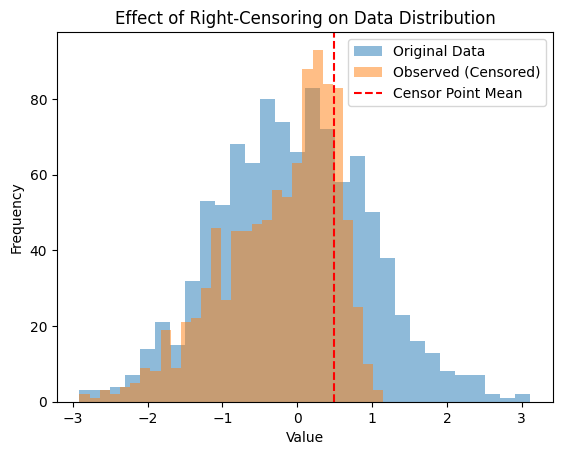

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Naive model (ignores censoring):

                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -0.25      0.02     -0.25     -0.29     -0.21   5704.42      1.00
     sigma      0.76      0.02      0.76      0.73      0.78   6441.66      1.00

Number of divergences: 0
None
Censored model (accounts for censoring):

                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -0.05      0.03     -0.05     -0.11      0.00   6525.84      1.00
     sigma      1.00      0.03      1.00      0.96      1.05   6232.74      1.00

Number of divergences: 0
None


In [2]:
## Simulate right-censored data and compare models
rng_key = random.PRNGKey(0)
key_x, key_censor = random.split(rng_key)
n = 1000  # Number of samples

# Generate original data from a Normal distribution
x_orig = dist.Normal(0, 1).sample(key_x, (n,))
censor_point = dist.Normal(0.5, 0.25).sample(key_censor, (n,))  # Censoring threshold
is_censored = x_orig > censor_point  # Boolean mask for censored observations
x_observed = jnp.where(
    is_censored, censor_point, x_orig
)  # Observed data: censored values replaced by censror point, the last observed time point

# Visualize original and observed (censored) data
plt.hist(x_orig, bins=30, alpha=0.5, label="Original Data")
plt.hist(x_observed, bins=30, alpha=0.5, label="Observed (Censored)")
plt.axvline(censor_point.mean(), color="r", linestyle="--", label="Censor Point Mean")
plt.legend()
plt.title("Effect of Right-Censoring on Data Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


# Naive model: ignores censoring, treats all data as observed
def model_naive(x):
    mu = numpyro.sample("mu", dist.Normal(0, 10))
    sigma = numpyro.sample("sigma", dist.HalfCauchy(5))
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=x)


# Censored model: uses RightCensoredDistribution to account for censored observations
def model_censored(x, censored):
    mu = numpyro.sample("mu", dist.Normal(0, 10))
    sigma = numpyro.sample("sigma", dist.HalfCauchy(5))
    with numpyro.plate("data", x.shape[0]):
        base_dist = dist.Normal(mu, sigma)
        censored_dist = RightCensoredDistribution(base_dist, censored=censored)
        numpyro.sample("obs", censored_dist, obs=x)


# Run MCMC for both models and print summaries
mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x_observed)
mcmc_censored = MCMC(
    NUTS(model_censored), num_warmup=1000, num_samples=2000, num_chains=4
)
mcmc_censored.run(rng_key, x_observed, is_censored)
print("Naive model (ignores censoring):")
print(mcmc_naive.print_summary())
print("Censored model (accounts for censoring):")
print(mcmc_censored.print_summary())

### Left-Censored Data Example
Left-censoring occurs when we only know that an observation is below a certain threshold. This is common in detection limit scenarios (e.g., measurements below a device's sensitivity).
Another example is when we know that a patient has a disease but the exact onset time is unknown, only that it occurred before a certain time point.
Here, we simulate left-censored data and fit both naive and censored models.

In [3]:
# Simulate left-censored data from a HalfNormal distribution
rng_key = random.PRNGKey(1)
kx, kc = random.split(rng_key)
x_orig = dist.HalfNormal(2).sample(kx, (100,))  # True data
tc = dist.HalfNormal(1.5).sample(kc, (100,))  # Censoring threshold
c = x_orig < tc  # Censoring indicator
x = jnp.where(c, tc, x_orig)  # Observed data


# Model that accounts for left-censoring
def model_left(x, c):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    with numpyro.plate("data", len(x)):
        cens_dist = LeftCensoredDistribution(dist.HalfNormal(scale), censored=c)
        numpyro.sample("obs", cens_dist, obs=x)


# Run MCMC for both models and compare results
mcmc_left = MCMC(NUTS(model_left), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_left.run(rng_key, x, c)
mcmc_left.print_summary()

mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x)
mcmc_naive.print_summary()
# Interpretation: The censored model should provide more accurate estimates when left-censoring is present.

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      2.07      0.15      2.06      1.82      2.32   2559.29      1.00

Number of divergences: 0


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      2.01      0.12      2.01      1.81      2.21   5604.55      1.00
     sigma      1.20      0.09      1.20      1.06      1.33   5917.10      1.00

Number of divergences: 0


### Left-censored data from a Weibull distribution

In [4]:
# Simulate left-censored data from a Weibull distribution
rng_key = random.PRNGKey(1)
kx, kc = random.split(rng_key)
x_orig = dist.Weibull(2, 0.5).sample(kx, (100,))  # True data
tc = dist.HalfNormal(1.5).sample(kc, (100,))  # Censoring threshold
c = x_orig < tc  # Censoring indicator
x = jnp.where(c, tc, x_orig)  # Observed data


# Model that accounts for left-censoring
def model_left(x, c):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    concentration = numpyro.sample("concentration", dist.HalfNormal(10))
    with numpyro.plate("data", len(x)):
        cens_dist = LeftCensoredDistribution(
            dist.Weibull(scale, concentration), censored=c
        )
        numpyro.sample("obs", cens_dist, obs=x)


# Run MCMC for both models and compare results
mcmc_left = MCMC(NUTS(model_left), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_left.run(rng_key, x, c)
mcmc_left.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
  concentration      0.52      0.05      0.52      0.44      0.60   4444.29      1.00
          scale      2.57      0.56      2.52      1.63      3.40   4568.14      1.00

Number of divergences: 0


## Interval-Censored Data Example: Real Support
Interval censoring occurs when the true value is only known to lie within a specific interval. This is common when measurements are taken at discrete time points, and the event occurs between two observations.

In this section:
- We simulate interval-censored data.
- Show how to encode left, right, and interval censoring.
- Fit a model using `IntervalCensoredDistribution`.

In [5]:
# Simulate interval-censored data
rng_key = random.PRNGKey(3)

kx, kl, kr = random.split(rng_key, 3)
x_orig = dist.Normal(0, 1).sample(kx, (1000,))
left = dist.Normal(-1, 0.5).sample(kl, (1000,))  # Left censoring threshold
right = dist.Normal(1.5, 0.25).sample(kr, (1000,))  # Right censoring threshold

# Initialize censoring bounds
# we can pick any values here, as they will be ignored/replaced by the censoring logic below
x1 = jnp.zeros_like(x_orig)  # Lower bound
x2 = jnp.zeros_like(x_orig)  # Upper bound

# Apply censoring logic
x1 = jnp.where(x_orig > right, right, x1)  # Right censored
x2 = jnp.where(x_orig < left, left, x2)  # Left censored
# Interval censored: value is between left and right
x1 = jnp.where((x_orig >= left) & (x_orig <= right), left, x1)
x2 = jnp.where((x_orig >= left) & (x_orig <= right), right, x2)

# stack the data into (n, 2) shape for interval censoring
x = jnp.stack([x1, x2], axis=-1)  # Observed intervals

# classify censoring types for analysis
left_censored = x_orig < left
right_censored = x_orig > right
censor_type = jnp.where(x_orig < left, -1, 0)  # left censored
censor_type = jnp.where(x_orig > right, 1, censor_type)  # right censored
censor_type = jnp.where(
    (x_orig >= left) & (x_orig <= right), 2, censor_type
)  # interval censored

# Store results in a DataFrame for inspection
df = pd.DataFrame(
    dict(x=x_orig, left=left, right=right, x1=x1, x2=x2, censor_type=censor_type)
)
df.censor_type = df.censor_type.map(
    {-1: "left", 0: "observed", 1: "right", 2: "interval"}
)
print(df.head(10))


# Model for interval-censored data
def model_interval(x, left_censored, right_censored):
    loc = numpyro.sample("loc", dist.Normal(0, 10))
    scale = numpyro.sample("scale", dist.HalfNormal(10))

    with numpyro.plate("data", len(x)):
        base_dist = dist.Normal(loc, scale)
        cens_dist = IntervalCensoredDistribution(
            base_dist, left_censored, right_censored
        )
        numpyro.sample("obs", cens_dist, obs=x)


# Run MCMC and print summary
mcmc_interval = MCMC(
    NUTS(model_interval), num_warmup=1000, num_samples=2000, num_chains=4
)
mcmc_interval.run(rng_key, x, left_censored, right_censored)
mcmc_interval.print_summary()

          x      left     right        x1        x2 censor_type
0 -2.378340 -1.971611  1.353055  0.000000 -1.971611        left
1 -1.706167 -0.947592  0.886214  0.000000 -0.947592        left
2 -0.491396 -1.023795  1.848583 -1.023795  1.848583    interval
3 -0.963126 -0.847003  1.632567  0.000000 -0.847003        left
4  0.190212 -1.152520  1.809663 -1.152520  1.809663    interval
5  1.113901 -1.540609  1.217351 -1.540609  1.217351    interval
6  0.752592 -1.393004  1.474636 -1.393004  1.474636    interval
7 -2.125727 -1.302301  1.388605  0.000000 -1.302301        left
8  2.441469 -0.103725  1.442812  1.442812  0.000000       right
9 -1.128319 -0.838085  1.510953  0.000000 -0.838085        left


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       loc     -0.03      0.04     -0.03     -0.10      0.04   7709.06      1.00
     scale      1.07      0.03      1.07      1.02      1.12   7674.72      1.00

Number of divergences: 0


## Right-Censored Weibull Example
The Weibull distribution is widely used in survival analysis and reliability engineering to model time-to-event data.

In this section:
- We simulate survival times from a Weibull distribution.
- Apply right-censoring to a subset of the data.
- Fit a censored Weibull model using Numpyro.
- Discuss how censoring affects parameter estimation.

In [6]:
# Simulate right-censored survival times from a Weibull distribution
scale = 1.0  # True scale parameter
concentration = 2.0  # True shape parameter
censor_prob = 0.2  # Probability of censoring
n = 1000  # Number of samples

key = random.PRNGKey(0)
key_time, key_censor, key = random.split(key, 3)
wb = dist.Weibull(scale, concentration)
times_orig = wb.sample(key_time, (n,))  # Simulated survival times
is_censored = dist.Bernoulli(censor_prob).sample(
    key_censor, (n,)
)  # Censoring indicator
censor_time = times_orig * dist.Uniform().sample(key, (n,))  # Censoring times
times_observed = jnp.where(
    is_censored, censor_time, times_orig
)  # Observed times with censoring applied

# Save simulated data for inspection or reuse
df = pd.DataFrame(
    {
        "time_orig": times_orig,
        "time_observed": times_observed,
        "is_censored": is_censored,
    }
)
print(df.head(10))


# Model definition for censored Weibull data
def model_weibull(times, is_censored):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    concentration = numpyro.sample("concentration", dist.HalfNormal(10))
    wb = dist.Weibull(scale, concentration)
    with numpyro.plate("data", len(times)):
        wbc = RightCensoredDistribution(wb, censored=is_censored)
        numpyro.sample("obs", wbc, obs=times)


# Run MCMC to fit the censored Weibull model and print summary
mcmc_weibull = MCMC(
    NUTS(model_weibull), num_warmup=1000, num_samples=2000, num_chains=4
)
mcmc_weibull.run(key, times_observed, is_censored)
mcmc_weibull.print_summary()

   time_orig  time_observed  is_censored
0   1.359099       1.226518            1
1   0.448727       0.409370            1
2   0.507648       0.507648            0
3   0.358690       0.358690            0
4   0.461478       0.461478            0
5   1.131454       0.574253            1
6   1.204188       0.863648            1
7   0.406832       0.406832            0
8   1.740820       1.028857            1
9   0.172478       0.172478            0


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
  concentration      2.06      0.06      2.06      1.97      2.16   5745.90      1.00
          scale      1.03      0.02      1.03      1.00      1.06   6455.95      1.00

Number of divergences: 0


## Interval censored Weibull model

In [7]:
# Simulate interval-censored data
rng_key = random.PRNGKey(0)

kx, kl, kr = random.split(rng_key, 3)
scale = 1.0
concentration = 1.0
x_orig = dist.Weibull(scale, concentration).sample(kx, (1000,))
left = dist.HalfNormal(0.25).sample(kl, (1000,))  # Left censoring threshold
right = dist.HalfNormal(2).sample(kr, (1000,))  # Right censoring threshold

# Initialize censoring bounds
# we can pick any values here, as they will be ignored/replaced by the censoring logic below
x1 = jnp.zeros_like(x_orig)  # Lower bound
x2 = jnp.zeros_like(x_orig)  # Upper bound

# Apply censoring logic
x1 = jnp.where(x_orig > right, right, x1)  # Right censored
x2 = jnp.where(x_orig < left, left, x2)  # Left censored
# Interval censored: value is between left and right
x1 = jnp.where((x_orig >= left) & (x_orig <= right), left, x1)
x2 = jnp.where((x_orig >= left) & (x_orig <= right), right, x2)

# stack the data into (n, 2) shape for interval censoring
x = jnp.stack([x1, x2], axis=-1)  # Observed intervals

# classify censoring types for analysis
left_censored = x_orig < left
right_censored = x_orig > right
censor_type = jnp.where(x_orig < left, -1, 0)  # left censored
censor_type = jnp.where(x_orig > right, 1, censor_type)  # right censored
censor_type = jnp.where(
    (x_orig >= left) & (x_orig <= right), 2, censor_type
)  # interval censored

# Store results in a DataFrame for inspection
df = pd.DataFrame(
    dict(x=x_orig, left=left, right=right, x1=x1, x2=x2, censor_type=censor_type)
)
df.censor_type = df.censor_type.map(
    {-1: "left", 0: "observed", 1: "right", 2: "interval"}
)
print(df.head(10))
print(df.censor_type.value_counts())


# Model for interval-censored data
def model_interval_weibull(x, left_censored, right_censored):
    scale = numpyro.sample("scale", dist.HalfCauchy(2.5))
    concentration = numpyro.sample("concentration", dist.HalfCauchy(2.5))
    base_dist = dist.Weibull(scale, concentration)

    with numpyro.plate("data", len(x)):
        cens_dist = IntervalCensoredDistribution(
            base_dist, left_censored, right_censored
        )
        numpyro.sample("obs", cens_dist, obs=x)


# Run MCMC and print summary
mcmc_interval_weibull = MCMC(
    NUTS(model_interval_weibull), num_warmup=2000, num_samples=2000, num_chains=4
)
mcmc_interval_weibull.run(rng_key, x, left_censored, right_censored)
mcmc_interval_weibull.print_summary()

          x      left     right        x1        x2 censor_type
0  1.847150  0.610614  2.591272  0.610614  2.591272    interval
1  0.201356  0.508920  2.710021  0.000000  0.508920        left
2  0.257707  0.051386  0.819211  0.051386  0.819211    interval
3  0.128658  0.088388  1.543771  0.088388  1.543771    interval
4  0.212962  0.190494  0.761883  0.190494  0.761883    interval
5  1.280188  0.294638  0.037778  0.037778  0.000000       right
6  1.450068  0.287055  1.149113  1.149113  0.000000       right
7  0.165512  0.074291  1.506558  0.074291  1.506558    interval
8  3.030454  0.327634  0.460332  0.460332  0.000000       right
9  0.029749  0.532551  2.978687  0.000000  0.532551        left
censor_type
interval    500
right       320
left        180
Name: count, dtype: int64


  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
  concentration      0.98      0.04      0.98      0.91      1.04   6488.79      1.00
          scale      0.98      0.04      0.98      0.91      1.05   6302.10      1.00

Number of divergences: 0


## Double censored data

In **double censoring**, the exact value of a latent variable \(x\) is not observed, but we only know that it lies **outside** a certain random range \((a, b)\).  

- **Left censoring:** we only know \(x < a\).  
- **Right censoring:** we only know \(x > b\).  
- **Interval censoring:** we only know \(a < x < b\).  
- **Double censoring:** we only know \(x \notin (a,b)\), i.e. \(x < a\) or \(x > b\).

A natural way to think about this observation process is through a “detector”:  
- The detector inspects a random interval \((a,b)\).  
- If \(x\) falls inside, we record an **interval-censored** observation.  
- If \(x\) falls outside, we record a **doubly censored** observation (both left and right).  

Thus the likelihood contribution for a single observation depends on which case occurs:
- Interval censored: \(P(a < X < b) = F(b) - F(a)\).  
- Left censored: \(P(X < a) = F(a)\).  
- Right censored: \(P(X > b) = 1 - F(b)\).  
- Double censored: \(P(X < a \text{ or } X > b) = F(a) + (1 - F(b))\).

In [8]:
n = 1000
key = random.PRNGKey(0)
key_x, key_left, key_window = random.split(key, 3)
window_size = 1.0

x = dist.Normal(0, 1).sample(key_x, (n,))
left = dist.Normal(0, 0.75).sample(key_left, (n,))  # Left censoring threshold
window_size = dist.Exponential(1.0).sample(key_window, (n,))
right = left + window_size

left_censored = (x < left) | (x > right)
right_censored = (x > right) | (x < left)

# make model
y_obs = jnp.stack([left, right], axis=-1)


def model_double_censored(y, left_censored, right_censored):
    mu = numpyro.sample("mu", dist.Normal(0, 10))
    sigma = numpyro.sample("sigma", dist.HalfCauchy(5))
    with numpyro.plate("data", y.shape[0]):
        base_dist = dist.Normal(mu, sigma)
        censored_dist = IntervalCensoredDistribution(
            base_dist, left_censored=left_censored, right_censored=right_censored
        )
        numpyro.sample("obs", censored_dist, obs=y)


mcmc_double_censored = MCMC(
    NUTS(model_double_censored), num_warmup=1000, num_samples=2000, num_chains=4
)
mcmc_double_censored.run(
    random.PRNGKey(1), y_obs, left_censored=left_censored, right_censored=right_censored
)
mcmc_double_censored.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -0.00      0.09     -0.00     -0.15      0.14   6604.24      1.00
     sigma      1.06      0.09      1.05      0.92      1.20   6249.80      1.00

Number of divergences: 0
